# Auditing Electrical Grid Stability (UCI #471)

A simulated smart-grid dataset used in hundreds of notebooks and papers as a classification benchmark. The audit recovers, from the CSV alone, the fact that the label is the **sign of a shipped column**.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd() if (Path.cwd() / 'datasets').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
from synthaudit import Audit
df = pd.read_csv(ROOT / 'datasets' / 'grid_stability.csv')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [2]:
audit = Audit(df, target='stabf', name='grid_stability',
              metadata={'generator_described': True, 'generator_code_available': False,
                        'seed_reported': False, 'artifacts_disclosed': True})
results = audit.run()

[synthaudit] auditing 'grid_stability' (10,000 rows x 14 cols, target=stabf)


[synthaudit] profile: 13 numeric, 1 categorical, 0 duplicate rows


[synthaudit] identity mining: 2 exact, 0 near identities, 0 FDs, 0 rule-derived labels


[synthaudit] determinism sweep: 0 deterministic, 2 near-deterministic columns


[synthaudit] causal scan: 12 edges on stochastic core (1 columns excluded)


[synthaudit] leakage audit: 3 critical, 0 high findings


[synthaudit] BTI = 0.256 (grade F) pillars={'L': 0.0, 'F': 0.8462, 'H': 1.0, 'R': 0.7179, 'I': 1.0, 'T': 0.5}


[synthaudit] done in 15.62s


In [3]:
for f in results['identity']['identities']:
    print(f"{f['type']:24s} disposition={f.get('disposition','?'):22s} {f.get('equation','')[:60]}")

linear                   disposition=structural_constraint  p4 = -1*p1 -1*p2 -1*p3
threshold_derivation     disposition=target_leakage         stabf == 'unstable'  iff  stab > -7.88345e-07


Two relations, two different verdicts. The threshold derivation involves the target: `target_leakage`. The power balance `p4 = -(p1+p2+p3)` lives among inputs: a `structural_constraint`, correct physics, not leakage.

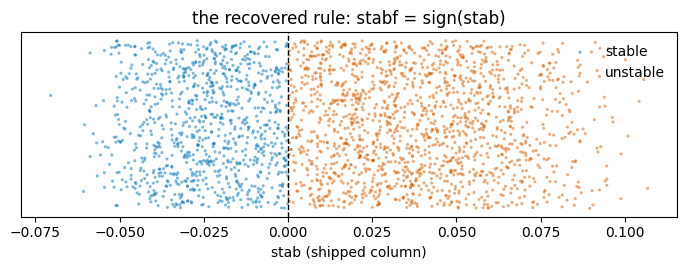

In [4]:
import matplotlib.pyplot as plt
import numpy as np
s = df.sample(2500, random_state=0)
colors = {'stable': '#0072B2', 'unstable': '#D55E00'}
fig, ax = plt.subplots(figsize=(7, 2.8))
for lab, g in s.groupby('stabf'):
    ax.scatter(g['stab'], np.random.default_rng(1).uniform(0, 1, len(g)),
               s=5, alpha=.5, label=lab, color=colors[lab], edgecolors='none')
ax.axvline(0, ls='--', c='k', lw=1)
ax.set_xlabel('stab (shipped column)'); ax.set_yticks([]); ax.legend(frameon=False)
ax.set_title('the recovered rule: stabf = sign(stab)')
plt.tight_layout()

In [5]:
print('grade:', results['scoring']['grade'], '| BTI:', results['scoring']['bti'])
print('honest view:', results['recommendations']['recommended_feature_view'])
print('honest model:', results['scoring']['evidence']['honest_model_score'],
      'vs baseline', results['scoring']['evidence']['honest_baseline'])

grade: F | BTI: 0.2556
honest view: ['g1', 'g2', 'g3', 'g4', 'p1', 'p2', 'p3', 'tau1', 'tau2', 'tau3', 'tau4']
honest model: 0.9421 vs baseline 0.6485


The verdict: grade F for the shipped task, because reported near-perfect accuracies measure equation recovery. The honest task (predict `stabf` without `stab`) remains meaningful at about 94% against a 65% base rate, and the recommendations name it.